# [실습] 세그먼트 요율표 — 표본 적은 세그먼트 안정화

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 어제의 한 숫자에서 242개 세그먼트로

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">모형추정 심화통계 · Day 2</div>
<h1 style="color:#000000;margin:10px 0">세그먼트 요율표 — 표본 적은 세그먼트 안정화</h1>
<div style="font-size:1.05em;color:#656565">요율 산정 프로젝트(5일) 2일차 — 프랑스 자동차보험 계약 678,013건</div>
</div>

## 오늘 할 일

프랑스 자동차보험사의 **프라이싱(요율 산정) 분석가** 업무 둘째 날입니다. 어제는 우도가 최대가 되는 추정값(MLE) 1개를 계산했습니다. 오늘은 그 추정값에 회사의 과거 경험을 사전분포로 반영합니다.

오늘의 과업은 팀장이 요청한 한 문장에서 출발합니다 — **"우리 회사가 보유한 계약 전체의 연간 사고율을, 근거와 함께, 하나의 숫자로 보고하라."** 절 순서대로 목표 4개를 정리합니다.

1. **한 숫자** — 계약 678,013건의 연간 사고율을 노출로 보정해 한 값으로 계산합니다(미션 1). 이론 4절이 공식으로 산출한 0.1006건/년을 수치 최적화로 다시 계산해 소수점 아래 6자리까지 대조합니다.
2. **요율표** — 지역 × 브랜드 조합 세그먼트마다 사고율을 따로 적어 요율표 초안을 작성합니다(미션 2).
3. **수축** — 관측이 적은 세그먼트의 추정값을 감마 사전분포로 안정시킵니다(미션 3).
4. **유무 전환** — 측정 지표를 사고 건수에서 사고 유무로 바꿔 같은 절차를 한 번 더 적용하고, **지역 2개의 사후분포를 비교해** 어느 쪽의 사고 경험률이 더 높은지를 확률 1개로 답합니다(과제).

어제는 사고 발생 여부만 0/1 로 집계해, 마력까지 세분한 세그먼트에서 추정값의 불확실성이 큰 세그먼트를 구분했습니다. 오늘은 측정 지표를 **관측 기간으로 나눈 사고율**로 바꾸고, 세그먼트 기준도 **지역 × 브랜드**로 다시 정의해 그 조합부터 다시 집계합니다.

수업에서 함께 진행하는 것은 미션 1·2 와 정리이고, 미션 3 과 과제는 방과후에 수행합니다. 뒤로 미루더라도 정리를 먼저 읽으면 결론이 이어집니다. 코드 작성은 대부분 AI 에 위임하고, 우리는 **지시할 내용을 정하고 받은 결과를 확인하는 역할**을 담당합니다.

## 오늘의 데이터

**freMTPL2freq** 는 프랑스 자동차 책임보험(Motor Third-Party Liability)의 실제 계약 기록입니다. 계약 한 건이 한 행이고 678,013행 × 12컬럼이며, 공개 저장소 OpenML 에서 로그인 없이 내려받습니다. 어제 규칙을 고정해 둔 컬럼은 아래 2개이고, 뒤쪽 미션에서는 여기에 지역 `Region` 과 차량 브랜드 `VehBrand` 2개 열을 세그먼트 기준으로 추가해 사용합니다. 이론 4절에서 함께 다룬 마력 등급 `VehPower` 는 오늘 사용하지 않고, 이론 5절에서 이름만 언급한 도시화 등급 `Area` 는 형 변환과 첫 미리보기 표에만 등장하며 오늘 계산에는 사용하지 않습니다.

| 컬럼 | 뜻 | 단위 | 받자마자 고정하는 규칙 |
|---|---|---|---|
| `ClaimNb` | 보험 기간 중 사고(청구) 건수 | 건 | 상한 4건에서 절사 — 4건을 넘는 사고가 기록된 계약이 소수 포함되어 있어, 그 몇 건이 전체 평균을 왜곡하지 않게 하는 관례적 전처리입니다 |
| `Exposure` | 그 계약이 실제로 유지된 기간, 곧 **노출** | 년 | 상한 1.0년에서 절사 — 1년을 초과해 2년까지 기록된 계약이 소수 포함되어 있어 같은 이유로 절사합니다 |

계약 4건 중 3건이 1년을 채우지 못하고 종료되어 계약 1건의 평균 노출은 0.53년입니다. 사고 건수만 세면 관측 기간이 달라 비교가 성립하지 않습니다. 노출이 사고율의 분모가 되는 이유입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Japanese_car_accident.jpg" width="640" height="360"/>
<p align="center"><em>▲ 교차로 접촉 사고 — 이 데이터의 각 행은 이런 사고 기록 1건에 대응한다. 계약별 사고 건수에서 공정한 보험료를 역산하는 것이 이번 실습의 목표</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia, Japanese_car_accident.jpg</span></p>

## 이 노트북을 쓰는 법

**환경 안내** — ▶ 실행은 Google Colab 연결 안내를 따르고, AI 튜터는 상단 「Claude 도우미」를 설치한 뒤 사용합니다(온보딩 레슨 참고). **채점은 Colab 이 연결되면 자동으로 준비됩니다 — 코드 패널 상단의 「채점 준비됨」이 표시된 뒤 미션을 시작하고, 미션 셀을 실행했는데 채점 결과가 출력되지 않으면 그 「채점 준비됨」을 누르세요.**

노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 뒤 시작합니다(코드는 접혀 있어도 실행됩니다). 도우미 대신 다른 AI 도구에 PROMPT 를 전달해 받은 코드를 `# --- 여기부터 AI 코드 ---` 아래에 직접 붙여 넣습니다. 채점이 끝나 🔓 가 표시되면 그 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 비교합니다.

**맨 위 설치·폰트 셀을 먼저 실행하세요 — 1회만 실행하면 되고, 채점 셀은 LMS 가 자동으로 실행합니다.** 미션마다 코드 셀이 2개입니다. 앞의 것은 그대로 실행하는 **준비 셀**이고, 뒤의 것은 지시할 내용을 적는 **PROMPT 셀**입니다.

PROMPT 셀의 `PROMPT` 에 지시할 내용을 직접 작성해 AI 에 전달하면, `# --- 여기부터 AI 코드 ---` 아래가 AI 가 코드를 작성하는 위치가 됩니다.

셀을 실행하면 **실행 결과(출력)에 채점 결과**가 함께 표시됩니다. 기준을 충족하면 완성본 풀이가 열리고, 미달이면 미달한 항목과 AI 튜터에 보낼 질문이 표시됩니다. 변수 이름은 자유롭게 정해도 됩니다. 채점 기준은 변수 이름이 아니라 셀이 출력한 값과 그림이기 때문입니다.

「준비 셀」은 미션마다 사용할 변수를 처음부터 정의하므로, 맨 위 설치·폰트 셀을 1회 실행해 두었다면 뒤쪽 미션만 따로 열어도 그 셀부터 실행하면 됩니다.

**주고받기 규칙 2개** — AI 와의 대화가 진전되지 않을 때는 다음 2개를 적용합니다.

| 이럴 때 | 이렇게 합니다 |
|---|---|
| 같은 요구를 두 번째 되풀이하게 될 때 | 표현을 바꾸지 말고 `PROMPT` 에 **누락된 조건을 1개** 추가합니다 |
| 조건을 추가해도 해결되지 않을 때 | 앞 대화를 이어서 사용하지 말고, 요구 사항 전체를 한 번에 다시 작성해 새 메시지로 전달합니다 |

In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "seaborn>=0.13" "scikit-learn>=1.3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gammaln
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 폰트 목록에는 그 설치가 반영되지 않으므로 addfont 로
#  등록해야 이름이 보인다(등록하지 않으면 DejaVu Sans 로 대체되어 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 축소되지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 자동 조정
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 제거해 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 4개가 함께 쓰는 색 — 사전=남색, 우도=파랑, 사후·강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 4개 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT,
      "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


## 로그우도 최댓값의 위치를 소수점까지 확정할 수 있을까

### 미션 1 — 포트폴리오 사고율 λ̂ 의 점추정

#### 할 일 — 미션 1 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 나오는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 계약 678,013건을 하나의 집단으로 두면 연간 사고율은 얼마입니까?

이론 4절에서 전체 계약의 연간 사고율 0.1006건/년을 공식으로 이미 계산했습니다. 미션 1 은 같은 값을 음의 로그우도와 수치 최적화로 다시 계산해 소수점 아래 6자리까지 대조합니다.

#### 실행 전에 — 계획을 골라 보세요

포트폴리오의 연간 사고율을 구하는 절차로 어느 쪽을 쓸까요? 하나를 고르고, 왜 그것이 보고서의 근거가 되는지 한 문장 적으세요.

> **[예측] 포트폴리오의 연간 사고율을 구하는 절차로 어느 쪽을 쓸까요?**
>
> 1. 계약당 사고 건수의 평균을 그대로 보고한다
> 2. 사고 건수의 합을 노출의 합으로 나눈다
> 3. 포아송 로그우도를 적어 그 최댓값을 주는 $\lambda$를 수치 최적화로 찾는다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

추가로, 3개 중 **2개는 같은 값이 계산됩니다**. 어느 2개인지도 함께 적어 두세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `y` | 계약별 사고 건수, 678,013건 · 단위 건 | 고정 |
| `E` | 계약별 노출, 단위 년 | 고정 |
| `poisson_nll(lam)` | 사고율 후보 하나를 받아 음의 로그우도를 반환하는 함수 | 그대로 부른다 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **연간 사고율 λ̂** — 단위 건/년 · 소수점 아래 6자리 · `poisson_nll` 을 수치 최적화로 가장 작게 만드는 사고율
   - **음의 로그우도(NLL)** 는 로그우도에 마이너스를 곱해 최댓값 찾기를 최솟값 찾기로 바꾼 값입니다. 부호만 바꾸었으므로 최적해의 가로축 위치, 곧 $\lambda$ 는 변하지 않습니다
2. **총 노출** — 단위 년 · 소수점 아래 1자리 · `E` 를 전부 더한 값이고, 1번 나눗셈의 분모에 해당합니다
3. **추가할 한 행** — 최적화의 수렴 여부와 반복 횟수
   - 채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다
4. **그래프 한 장** — 가로축은 후보 연간 사고율 0.05 ～ 0.20, 세로축은 로그우도인 선 그래프
   - 곡선 : 후보를 촘촘히 나열한 로그우도 곡선 하나 — `poisson_nll` 에 마이너스를 곱한 값입니다
   - 수직선 : 1번에서 찾은 사고율 위치에 세로축 아래 끝부터 위 끝까지 곧은 선 하나 — 곡선은 로그우도 선 한 개뿐이고, 이 수직선은 곡선으로 세지 않습니다
   - 가로축 이름 : 「연간 사고율 $\lambda$ (건/년)」
   - 세로축 이름 : 「로그우도 $\ell(\lambda)$」

**출력 형식** — 「이름 = 값 단위」 형식으로 1행씩 `print` 합니다. 그래프는 한 장입니다.

통과하면 공식으로 바로 구하는 해(closed-form)와 수치 최적화 2가지가 같은 값을 주는지 소수점 아래 6자리까지 대조해 보세요. 이 대조가 미션 1 의 확인 항목입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `y` · `E` · `poisson_nll` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **최소화 대상** — 어느 함수를 가장 작게 만드는 사고율을 찾는지, 그리고 후보가 0 보다 크다는 것.
- **출력** — 값 2개의 이름과 단위, 소수점 아래 몇 자리까지 출력할지.
- **그래프** — 가로축 범위 · 세로축이 로그우도라는 것 · 수직선을 그을 위치 · 가로축·세로축 이름.

**막히면** — AI 튜터에게 「최소화 함수에 목적함수와 시작값을 어떻게 전달하나요」 처럼 물어보세요.

<details class="lms-extra"><summary>음의 로그우도를 최소화하는 이유</summary>

최적화 도구는 대개 최솟값을 찾도록 만들어져 있습니다. 그래서 최댓값을 찾는 문제를 부호만 바꿔 최솟값을 찾는 문제로 전달합니다 — 어제 4절에서 적은 로그우도를 그대로 쓰되, `minimize` 에 전달할 목적함수만 음의 로그우도로 둡니다. 세로축을 음의 로그우도로 그리면 곡선이 상하로 반전되어, 로그우도의 최댓값 지점이 그대로 최솟값 지점이 됩니다. 가로축 위치는 변하지 않으므로 수치 최적화가 찾은 $\lambda$ 도 같습니다.

부호만 바뀌므로 높이의 절댓값도 같습니다 — 완성본이 출력하는 로그우도 −146,624 와 음의 로그우도 +146,624 는 같은 지점의 두 표기입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Nelder-Mead_Rosenbrock.gif" width="440" height="440"/>
<p align="center"><em>▲ 수치 최적화가 후보값을 반복 계산하며 최솟값으로 이동하는 과정 — 빨간 삼각형이 후보값을 갱신하며 최솟값 위치로 수렴한다. 검은 곡선은 목적함수의 등고선이고, 우리가 <code>minimize</code> 에 전달할 목적함수가 바로 음의 로그우도다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia, Nelder-Mead_Rosenbrock.gif</span></p>

</details>

<details class="lms-extra"><summary>주의 — AI 에 위임할 것과 직접 확인할 것</summary>

도우미가 코드를 넣는 곳은 마지막으로 클릭한 코드 셀입니다. 다른 셀을 클릭한 채 시키면 엉뚱한 셀이 바뀝니다.

왼쪽은 문법과 기본 구조 작성이라 맡겨도 되는 일이고, 오른쪽은 **틀려도 오류가 나지 않아** 사람이 봐야 하는 일입니다.

| AI 에게 맡길 일 | 내가 반드시 확인할 일 |
|---|---|
| 최적화 호출 코드와 인자 채우기 | 최소화 대상이 **음의** 로그우도인가 |
| 후보 $\lambda$ 몇 개의 값을 나란히 출력 | 나눗셈의 분모가 계약 수가 아니라 **노출의 합**인가 |
| 로그우도 곡선을 그리고 수직선 긋기 | 수렴에 성공했는가, 값의 단위가 건/년으로 타당한가 |

</details>

In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 빈도 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 어제 정해 5일 내내 고정하는 전처리 규칙 2개
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 절사
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 노출은 1년 상한

y = df["ClaimNb"].to_numpy(dtype=float)      # 쓸 변수 1 — 계약별 사고 건수 (단위 건)
E = df["Exposure"].to_numpy(dtype=float)     # 쓸 변수 2 — 계약별 노출 (단위 년)


def poisson_nll(lam):                        # 쓸 변수 3 — 이론에서 만든 노출 보정 포아송의 음의 로그우도
    """lam 은 숫자 하나 또는 길이 1 배열. 최소화용이라 로그우도에 마이너스를 붙여 돌려줍니다"""
    lam = float(np.atleast_1d(lam)[0])
    if lam <= 0:
        return 1e12                          # 범위 밖 후보에는 큰 벌점
    return -np.sum(y * np.log(lam * E) - lam * E - gammaln(y + 1))


print("행 x 열 :", df.shape, "| 결측치 총합 :", int(df.isna().sum().sum()))
print(df[["IDpol", "ClaimNb", "Exposure", "Area", "VehBrand", "Region"]].head())
print("쓸 수 있는 이름 : y (사고 건수, 건) · E (노출, 년) · poisson_nll(lam) (음의 로그우도)")

행 x 열 : (678013, 12) | 결측치 총합 : 0
   IDpol  ClaimNb  Exposure Area VehBrand Region
0      1        1      0.10    D      B12    R82
1      3        1      0.77    D      B12    R82
2      5        1      0.75    B      B12    R22
3     10        1      0.09    B      B12    R72
4     11        1      0.84    B      B12    R72
쓸 수 있는 이름 : y (사고 건수, 건) · E (노출, 년) · poisson_nll(lam) (음의 로그우도)


연간 사고율 = 0.100614 건/년
총 노출 = 358360.1 년
수렴 여부 = True, 반복 횟수 = 2

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 연간 사고율 λ̂ (건/년) — 출력에서 0.100614 를 찾았습니다
✅ 총 노출 (년) — 출력에서 358,360 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


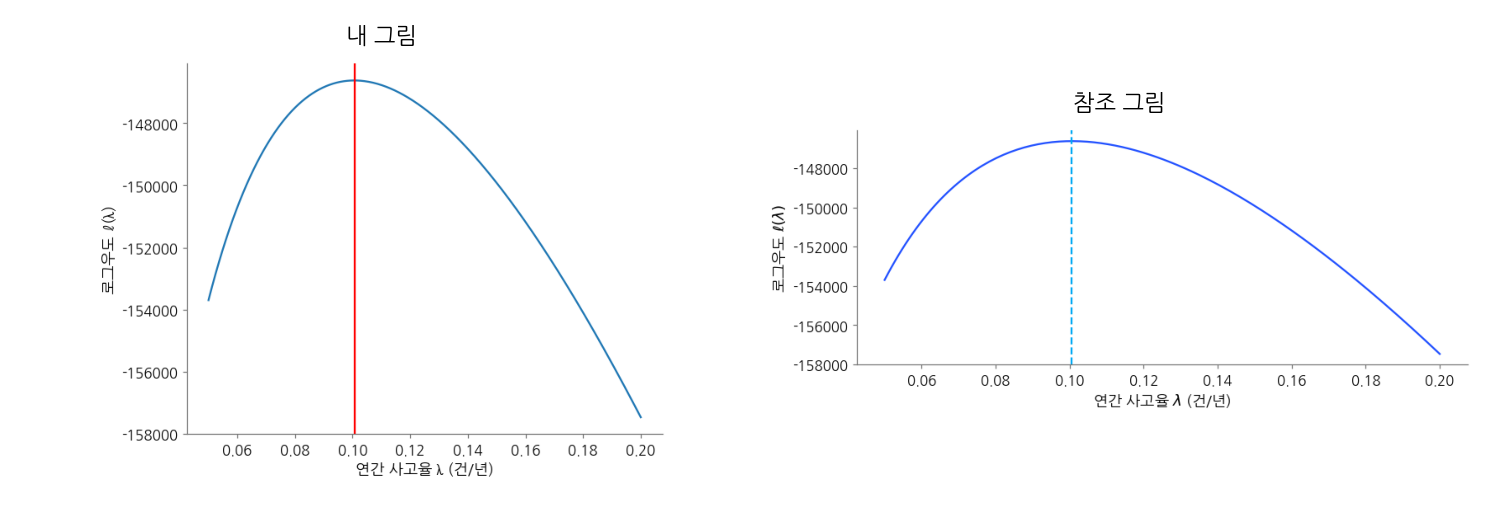

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
y, E, poisson_nll 은 이미 있으니 다시 만들지 말고 그대로 사용한다.

[할 일]
아래 네 가지를 계산/출력하는 코드를 PROMPT 셀 한 곳에 다 나오게 한다.

1. 연간 사고율
   - poisson_nll 을 수치 최적화로 가장 작게 만드는 사고율을 찾는다.
   - 사고율 후보는 0보다 커야 하며, 최적화 시 이 제약을 명시적으로 반영한다.
   - 단위: 건/년, 소수 여섯 자리로 출력

2. 총 노출
   - E를 전부 더한 값. 1번 나눗셈의 분모에 해당한다.
   - 단위: 년, 소수점 아래 한자리로 출력

3. 대조용 한 행
   - 최적화의 수렴 여부와 반복 횟수

4. 그래프 한 장
   - 후보를 촘촘히 나열한 로그우도 곡선하나를 그린다(poisson_nll 에 마이너스를 곱한 값)
   - 가로축: 후보 연간 사고율 0.05 ～ 0.20.    - 세로축: 로그우도
   - 수직선(axvline):1번에서 찾은 사고율 위치에 세로축 아래 끝부터 위 끝까지 곧은 선 하나 (이 수직선은 곡선으로 세지 않는다)
  - 가로축 이름: 연간 사고율 λ (건/년) 
  - 세로축 이름: 로그우도 ℓ(λ)

[출력 형식]
- "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

result = minimize(poisson_nll, x0=[0.1], bounds=[(1e-9, None)])
lam_hat = result.x[0]
total_exposure = E.sum()

print(f"연간 사고율 = {lam_hat:.6f} 건/년")
print(f"총 노출 = {total_exposure:.1f} 년")
print(f"수렴 여부 = {result.success}, 반복 횟수 = {result.nit}")

lams = np.linspace(0.05, 0.20, 500)
loglik = [-poisson_nll(lam) for lam in lams]

plt.figure()
plt.plot(lams, loglik)
plt.axvline(lam_hat, color='red')
plt.xlabel("연간 사고율 λ (건/년)")
plt.ylabel("로그우도 ℓ(λ)")
plt.show()

> **[문제] 미션 1 의 「여기부터 AI 코드」 아래 코드에서 `minimize` 에 넘긴 목적함수가 `poisson_nll` 인 것이 결과에 어떻게 작용하나요?**
>
> 1. 로그우도를 그대로 넘긴 것과 같아, 최적화가 로그우도의 최댓값을 향해 올라간다
> 2. 부호를 뒤집어 최솟값을 찾게 만든 것이라, 찾은 자리는 로그우도가 가장 큰 λ 와 같은 가로 위치다
> 3. 부호를 뒤집었으므로 찾은 λ 도 뒤집혀, 로그우도 최대 지점과는 다른 값이 나온다

## 세그먼트를 더 세분하면 요율표가 더 공정해질까

### 미션 2 — 지역 × 브랜드 요율표 (함정 미션)

#### 할 일 — 미션 2 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 「PROMPT 셀」을 **먼저 그대로 ▶** 해 전임 담당자 코드의 채점 결과(❌)를 봅니다.
3. 아래 고칠 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
4. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
5. 실행 결과(출력)에 나오는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 4번부터 다시 합니다.

**이 미션의 질문** — 지역 × 브랜드 세그먼트마다 연간 사고율을 적으면 값의 범위가 얼마나 됩니까?

전체 계약의 사고율 한 값만 보고했더니 팀장이 되묻습니다 — **"모든 계약에 같은 사고율을 매기면, 사고가 드문 시골 운전자가 대도시 운전자의 보험금을 대신 내 주는 구조 아닌가요?"** 그래서 이번에는 **세그먼트**(segment)마다 사고율을 따로 계산합니다. 세그먼트는 위험 수준이 비슷한 계약의 집합이고, 여기서는 지역과 브랜드가 같은 계약이 한 세그먼트입니다. 지역 22개와 브랜드 11개의 조합 중 계약이 실제로 있는 것만 남기므로 세그먼트 수는 만들 것 2번에서 계산합니다. 쓰는 식은 **이론 4절**의 노출 보정 추정 $\hat{\lambda} = \sum_i y_i / \sum_i E_i$ 그대로이고, 합을 내는 범위만 그 세그먼트 안으로 좁힙니다.

#### 고치기 전에 — 틀린 곳을 먼저 찾아보세요

「여기부터 AI 코드」 아래 코드를 한 행씩 읽고, 값이 아니라 **단위**로 검산해 보세요.

> **[예측] 아래 AI 코드는 실행되는데 답이 틀렸습니다. 틀린 곳은 어디이고 왜일까요?**
>
> 1. 집계 코드 행 — `.agg(...)` 가 사고 건수를 합이 아니라 개수로 세고 있어서
> 2. 사고율 코드 행 — 나눗셈의 분모가 노출의 합이 아니라 계약 수여서 단위가 건/계약이 된다
> 3. 출력 코드 행 — `.max()` 가 가장 높은 세그먼트가 아니라 표 전체의 최댓값을 읽고 있어서
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

지적한 곳에 근거 1문장을 적으세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `df` | 계약 678,013행 표, 열은 `ClaimNb` · `Exposure` · `Region` · `VehBrand` | 고정 |
| `group_keys` | 세그먼트 기준 열 2개 `Region` · `VehBrand` | 고정 |
| `lam_all` | 전체 계약(회사 전체)의 연간 사고율, 단위 건/년 · 대조용 | 고정 |
| `claims_all` | 원본 전체 사고 건수, 단위 건 · 대조용 | 고정 |

#### 고칠 것

「여기부터 AI 코드」 행 아래에 전임 담당자 코드가 이미 들어 있습니다. 오류 없이 실행되지만 값이 틀렸고 그림이 없습니다. 고친 뒤의 아래 3개가 이 미션에서 만들 것입니다.

1. **가장 높은 세그먼트의 사고율** — 단위 건/년 · 소수점 아래 6자리
   - 지금 : 분모가 잘못 지정되어 값이 절반 아래로 감소합니다
   - 고친 뒤 : 같은 사고 합을 그 세그먼트의 노출 합 `exposure` 로 나눕니다 — 계약 수로 나누면 단위가 건/계약이라 사고율이 아닙니다
   - 그 세그먼트의 이름도 「지역 × 브랜드」 형태로 같은 행에 함께 출력합니다. 다음 미션의 배경에서 이 세그먼트와 바로 아래 세그먼트를 함께 다룹니다
2. **세그먼트 수** — 단위 개 · 정수
   - 지금 : 표의 행 수를 세어 맞게 나옵니다. 이 행은 그대로 둡니다
3. **그래프 한 장** — 가로축은 세그먼트의 총 노출, 세로축은 그 세그먼트의 연간 사고율인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 242개
   - 가로축 척도 : 로그 척도 — 눈금 한 단계마다 값이 10배가 되는 척도이고, matplotlib 에서는 `ax.set_xscale("log")` 한 행입니다
   - 가로축 이름 : 「세그먼트 총 노출 (년, 로그 눈금)」
   - 세로축 이름 : 「연간 사고율 MLE (건/년)」
   - 지금 : 그림이 없습니다. 같은 프롬프트에서 새로 시켜야 나옵니다
   - 아래 깔때기 그림이 우리가 그릴 모양입니다

<img src="https://en.wikipedia.org/wiki/Special:FilePath/FloreAndWicherts2015_meta_analysis_sex_stereotype_threat.png" width="480" height="449"/>
<p align="center"><em>▲ 깔때기 그림(funnel plot) — 표본이 작은 연구일수록 추정값이 좌우로 넓게 흩어진다. 우리가 그릴 그림은 가로축에 총 노출, 세로축에 사고율을 배치해 같은 깔때기가 왼쪽에서 넓어진다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikimedia Commons, Flore &amp; Wicherts 2015 meta-analysis funnel plot</span></p>

**통과 기준** — 값 2개가 「이름 = 값 단위」 형식으로 1행씩 출력되고, 산점도 한 장이 위 요구를 다 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고칠 곳** — 세그먼트별 사고율을 만드는 나눗셈 1행, 그 분모를 무엇으로 바꿀지.
- **수정하지 말 범위** — `df` 와 `group_keys` 는 이미 있으니 데이터를 다시 읽지 말고 그대로 쓰라고 적습니다.
- **출력** — 값 2개의 이름과 단위, 소수점 아래 몇 자리까지 출력할지.
- **그래프** — 가로축·세로축에 무엇을 배치할지 · 가로축 척도 · 이름을 다는 것.

**막히면** — AI 튜터에게 「세그먼트별 사고율의 분모를 노출의 합으로 바꾸면 단위가 어떻게 달라지나요」 처럼 물어보세요.

<details class="lms-extra"><summary>가로축을 로그 척도로 두는 이유</summary>

세그먼트마다 총 노출이 2.4년부터 3만 년 넘게까지 분포합니다. 선형 척도에서는 점의 대부분이 왼쪽 끝에 밀집해 분포 형태가 드러나지 않습니다. 로그 척도는 눈금 한 단계마다 값이 10배가 되는 척도라, 노출이 1만 배 차이 나는 세그먼트도 한 화면에 고르게 배치됩니다.

눈금은 10 · 100 · 1,000 · 10,000 처럼 읽습니다. 가로축에서 오른쪽 눈금 한 단계는 그 세그먼트에 누적된 관측이 10배라는 뜻이고, 오른쪽으로 갈수록 세로축 방향 산포가 좁아지는 것이 이 미션에서 확인할 형태입니다. 어제 4절의 포아송 MLE $\hat{\lambda} = \bar{x}$ 에서 분모만 노출의 합으로 바꾼 식이라, 분모가 커질수록 추정값의 산포가 감소합니다.

</details>

<details class="lms-extra"><summary>깔때기 그림의 가로축·세로축과 점선</summary>

검은 점 하나가 연구 하나입니다. 가로축은 각 연구의 추정값이고, 세로축은 그 추정값의 표준오차(표본마다 추정값이 흩어지는 정도)라 표본이 클수록 0 에 가까워집니다. 그래서 위쪽에서는 점이 가운데로 모이고 아래로 갈수록 좌우로 넓게 흩어집니다. 점선과 회색 영역은 원 논문의 유의수준(귀무가설을 기각하는 기준) 표시라 지금은 넓어지는 형태만 확인하면 됩니다.

</details>

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

group_keys = ["Region", "VehBrand"]                           # 쓸 변수 1 — 세그먼트 기준 열 2개
lam_all = float(df["ClaimNb"].sum() / df["Exposure"].sum())   # 쓸 변수 2 — 전체 계약의 연간 사고율 (건/년), 대조용
claims_all = int(df["ClaimNb"].sum())                         # 쓸 변수 3 — 원본 전체 사고 건수 (건), 대조용

print("세그먼트 축 :", group_keys, "|",
      f'지역 {df["Region"].nunique()}개 x 브랜드 {df["VehBrand"].nunique()}개'
      " — 계약이 실제로 있는 조합이 몇 개인지는 표를 만들어 보면 나옵니다")
print(f"대조용 — 전체 계약 사고율 lam_all : {lam_all:.6f} 건/년"
      f" | 원본 사고 합 claims_all : {claims_all:,} 건")
print("쓸 수 있는 이름 :  df · group_keys · lam_all · claims_all")

세그먼트 축 : ['Region', 'VehBrand'] | 지역 22개 x 브랜드 11개 — 계약이 실제로 있는 조합이 몇 개인지는 표를 만들어 보면 나옵니다
대조용 — 전체 계약 사고율 lam_all : 0.100614 건/년 | 원본 사고 합 claims_all : 36,056 건
쓸 수 있는 이름 :  df · group_keys · lam_all · claims_all


가장 높은 세그먼트 사고율 = R43 × B4 = 0.309191 건/년
세그먼트 수 = 242 개

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ 세그먼트 수 (개) — 출력에서 242 를 찾았습니다
✅ 가장 높은 세그먼트의 사고율 (건/년) — 출력에서 0.309191 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


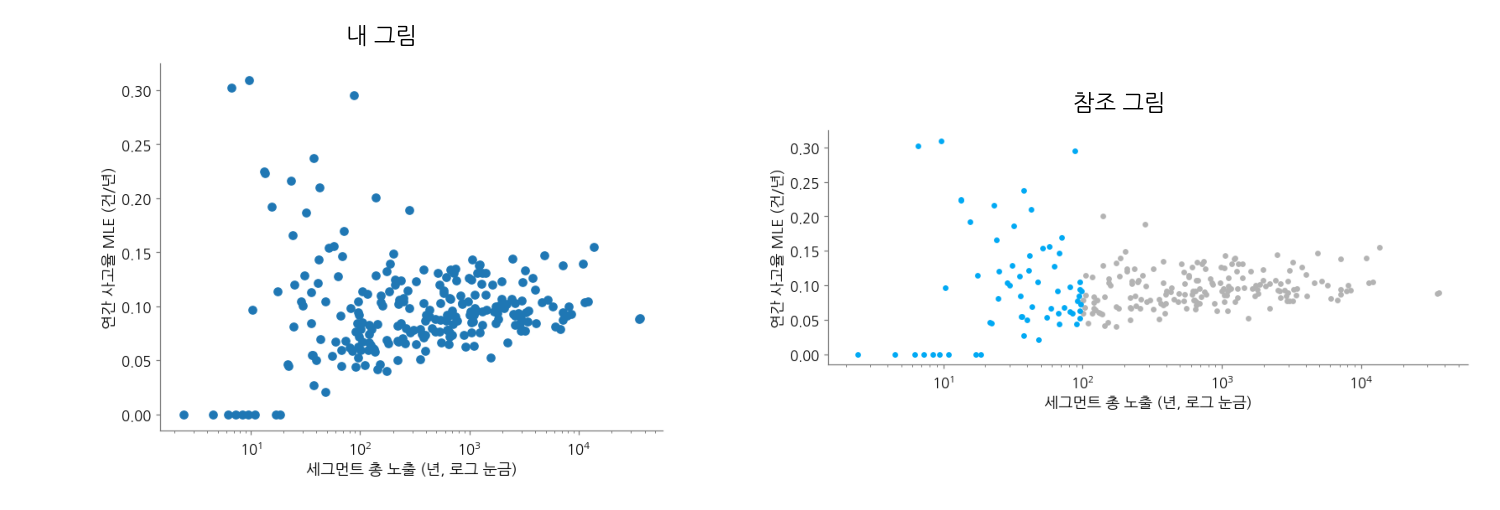

In [5]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 AI 튜터가 「여기부터 AI 코드」 아래를 다시 씁니다.
PROMPT = """
[전제]
df, group_keys 은 이미 있으니 다시 만들지 말고 그대로 사용한다.

[전임 담당자 코드 문제]
seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["n"]
가장 높은 세그먼트 사고율 계산에서 분모가 계약 수로 되어있다.

[할 일]
전임 담당자의 코드를 수정할 아래 세 가지를 계산/출력하는 코드를 PROMPT 셀 한 곳에 다 나오게 한다.

1. 가장 높은 세그먼트 사고율
   - 세그먼트별로 사고 합을 그 세그먼트의 노출 합 exposure 로 나눈다.
   - 그중 사고율이 가장 높은 세그먼트 1개만 찾는다.
   - 그 세그먼트의 이름도 「지역 × 브랜드」 형태로 같은 행에 함께 출력한다.

2. 세그먼트 수
   - 세그먼트 수 구하는 코드는 맞게 나오므로 그대로 둔다
   - 단위: 개, 정수

3. 그래프 한 장
   - 세그먼트 하나에 점 하나(총242개)인 산점도 그래프를 그린다.
   - 가로축: 세그먼트의 총 노출
   - 세로축: 그 세그먼트의 연간 사고율
   - 가로축 척도: 로그 척도. 눈금 한 단계마다 값이 10배가 되는 척도이고, matplotlib 에서는 ax.set_xscale("log") 한 행이다.
   - 가로축 이름: 세그먼트 총 노출 (년, 로그 눈금)
   - 세로축 이름: 연간 사고율 MLE (건/년)
   - 원래 코드에는 그래프가 없으므로 새로 제작한다.

[출력 형식]
- "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
# ↓ 전임 담당자의 코드 — 그대로 실행하면 채점이 ❌ 를 냅니다
# seg_fine = (df.groupby(group_keys, observed=True)
#               .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
#               .reset_index())
# seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["n"]

# print(f"세그먼트 수 : {len(seg_fine)} 개")
# print(f"가장 높은 세그먼트의 사고율 : {seg_fine['lam_mle'].max():.6f} 건/년"
#       f" | 가장 낮은 세그먼트 {seg_fine['lam_mle'].min():.6f}"
#       f" | 사고율 0 인 세그먼트 {int((seg_fine['lam_mle'] == 0).sum())} 개")
import matplotlib.pyplot as plt

seg_fine = (df.groupby(group_keys, observed=True)
              .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
              .reset_index())
seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["exposure"]
seg_fine["segment"] = seg_fine[group_keys[0]].astype(str) + " × " + seg_fine[group_keys[1]].astype(str)

top = seg_fine.loc[seg_fine["lam_mle"].idxmax()]
print(f"가장 높은 세그먼트 사고율 = {top['segment']} = {top['lam_mle']:.6f} 건/년")
print(f"세그먼트 수 = {len(seg_fine)} 개")

fig, ax = plt.subplots()
ax.scatter(seg_fine["exposure"], seg_fine["lam_mle"])
ax.set_xscale("log")
ax.set_xlabel("세그먼트 총 노출 (년, 로그 눈금)")
ax.set_ylabel("연간 사고율 MLE (건/년)")
plt.show()

> **[문제] 미션 2 에서 고친 뒤의 코드가 세그먼트별 사고율을 만드는 방식으로 맞는 것은?**
>
> 1. `.agg(n=("IDpol", "size"))` 가 센 계약 수로 사고 합을 나눈다 — 단위는 건/계약
> 2. 계약별 사고율을 먼저 구한 뒤 세그먼트 안에서 단순 평균한다 — 노출이 긴 계약도 같은 무게다
> 3. `.agg(exposure=("Exposure", "sum"))` 이 쌓은 노출의 합으로 사고 합을 나눈다 — 단위는 건/년

## 242개 세그먼트 중 수축이 크게 적용되는 것을 구분할 수 있을까

### 미션 3 — 242개 세그먼트에 감마 사전분포 적용

#### 할 일 — 미션 3 (25분)

1. 아래 「[직접 해보기] 관측이 적은 세그먼트의 수축」에서 위젯의 슬라이더를 조작해 어느 세그먼트가 크게 이동하는지 먼저 확인합니다.
2. 그 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
3. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
4. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
5. 실행 결과(출력)에 나오는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 4번부터 다시 합니다.

**이 미션의 질문** — 계약 12건에서 사고율이 과대 추정된 세그먼트에, 회사의 과거 경험을 반영하면 값이 어디에 위치합니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg_fine` | 세그먼트 242행 표, 열은 `n` · `claims` · `exposure` · `lam_mle` | 고정 |
| `watch` | 점검 대상 세그먼트 R21 × B11 한 행 | 고정 |
| `lam_all` | 전체 계약(회사 전체)의 연간 사고율, 단위 건/년 | 고정 |
| `alpha_0` | 감마 사전분포의 형상모수 α₀, 최빈값을 `lam_all` 에 맞춰 둔 값 | 고정 |
| `beta_0` | 감마 사전분포의 강도 β₀ = 가상 노출 100년 — 위젯 라벨 「사전 강도 β₀」와 같은 값 | 고정 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **R21 × B11 세그먼트의 MAP** — 단위 건/년 · 소수점 아래 6자리 · `watch` 한 행에 아래 MAP 공식을 넣은 값
2. **242개 세그먼트 MAP 의 최솟값** — 단위 건/년 · 소수점 아래 6자리 · 242개 전부에 MAP 를 적용한 뒤 가장 작은 값
   - 이 값이 0 보다 크면 사고율이 0 으로 계산되던 세그먼트가 하나도 남지 않았다는 뜻입니다
3. **추가할 한 행** — 같은 세그먼트의 `lam_mle` 와, `lam_mle` 가 0 이던 세그먼트 수
   - 채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다
4. **그래프 한 장** — 가로축은 세그먼트의 MLE, 세로축은 그 세그먼트의 MAP 인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 242개
   - 대각선 : 두 값이 같은 지점을 잇는 $y = x$ 선 하나 — 0 부터 MLE 최댓값까지 긋습니다
   - 가로축 이름 : 「MLE — 데이터가 말한 그대로 (건/년)」
   - 세로축 이름 : 「MAP — 감마 사전분포를 반영한 뒤 (건/년)」

**출력 형식** — 「이름 = 값 단위」 형식으로 1행씩 `print` 합니다. 표를 통째로 출력하면 채점이 어느 값을 읽을지 고르지 못합니다. 그래프는 한 장입니다.

#### 쓸 공식 — 사후분포의 최빈값(mode, MAP)

**감마분포**는 0 보다 큰 값에 정의되는 분포족이고 모수 2개로 모양이 정해집니다. 포아송 사고율의 켤레 사전분포라 오늘의 사전분포를 이 분포로 적습니다. 모수 2개 중 $\beta_0$ 는 **사전분포의 강도**이고 단위는 노출과 같은 년입니다 — 데이터를 보기 전에 가상 노출 $\beta_0$ 년을 이미 관측했다고 두는 값이고, 위젯 라벨 「사전 강도 β₀」가 이 값입니다. $\alpha_0$ 는 그 기간에 관측한 가상 사고 수에 1 을 더한 값입니다.

이론 3절의 **MAP** 는 사후분포의 최빈값을 요율로 쓰는 추정값이었습니다. 3절의 감마 갱신이 분모에 더한 관측 수 $n$ 항에 **노출의 합**을 대입한 것이 이론 5절이고, 그러면 최빈값이 아래 식 하나로 정리됩니다.

$$
\hat{\lambda}_{\text{MAP}} = \frac{\alpha_0 + \sum y_i - 1}{\beta_0 + \sum E_i}
$$

분자는 가상 사고 $\alpha_0 - 1$ 건과 실제 사고 $\sum y_i$ 의 합이고, 분모는 가상 노출 $\beta_0$ 년과 실제 노출 $\sum E_i$ 의 합입니다. 사전분포를 가상의 과거 데이터로 보면 이 식이 해석됩니다. 이론 5절은 $\beta_0 = 0$ 으로 두어 사전분포를 제외했고, 오늘은 그 $\beta_0$ 를 가상 노출 100년으로 되살립니다.

숫자를 넣어 보면 이렇습니다. 「준비 셀」이 $\beta_0 = 100$년으로 설정하고 $\alpha_0$ 를 전체 계약 사고율에 맞춰 11.06 으로 지정하므로, 분자에 미리 더해지는 가상 사고는 $\alpha_0 - 1 = 10.06$건이고 분모에는 가상 노출 100년이 이미 들어 있습니다. 계약 12건인 세그먼트의 실제 노출은 가상 노출 100년에 비해 비중이 매우 작습니다.

그래프의 **대각선**은 가로축 값과 세로축 값이 같은 지점을 잇는 선 $y = x$ 입니다. 그 선 위에 위치한 점이 이동하지 않은 세그먼트이고, 멀어질수록 많이 이동한 세그먼트입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `seg_fine` · `watch` · `alpha_0` · `beta_0` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **MAP 를 구하는 법** — 위 공식의 분자에 무엇을 더하고 무엇을 빼는지, 분모에 무엇을 더하는지.
- **출력** — 값 2개의 이름과 단위, 소수점 아래 몇 자리까지 출력할지.
- **그래프** — 가로축·세로축에 무엇을 배치할지 · 대각선의 양 끝 · 가로축·세로축 이름.

**막히면** — AI 튜터에게 「사고가 한 건도 없는 세그먼트에 MAP 공식을 적용하면 분자에 무엇이 남나요」 처럼 물어보세요.

#### 실행 전에 — 예상을 골라 보세요

사전분포는 242개 세그먼트 모두에 똑같이 적용됩니다. 그런데 노출이 1만 년을 넘는 대형 세그먼트의 이동 거리는 얼마입니까?

> **[예측] MLE 에서 MAP 로 옮길 때 노출이 1만 년을 넘는 대형 세그먼트는 소형 세그먼트와 견줘 얼마나 움직일까요?**
>
> 1. 소형 세그먼트와 비슷한 정도로 움직인다
> 2. 소형 세그먼트보다 훨씬 작게, 이동 거리가 0.001 에도 못 미친다
> 3. 아예 움직이지 않는다 — MLE 와 MAP 가 완전히 같은 값이다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 뒤에는 왜 그런지 근거 1문장을 함께 적어 두세요.

<details class="lms-extra"><summary>점검 대상 세그먼트가 R21 × B11 인 이유</summary>

미션 2 의 요율표에는 사고율이 0.00 으로 출력된 세그먼트가 9개 남았습니다. 가장 높은 R43 × B4 는 계약 26건이고, 사고율이 3배 수준으로 계산된 R21 × B11 의 계약은 12건뿐입니다. 관측이 더 적은 쪽을 **점검 대상 세그먼트**로 삼아 `watch` 에 지정해 두었습니다.

</details>

<details class="lms-extra"><summary>가상 노출 100년과 감마 사전분포를 그림으로 읽는 법</summary>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_Process.png" width="640" height="361"/>
<p align="center"><em>▲ 사고가 시간에 따라 누적되는 경로를 5회 모의 생성한 그림 — 선의 기울기가 곧 그 관측의 사고율 λ 다. 가로축 눈금 50 까지 가는 동안 보라색(λ = 10)은 약 510건, 파란색(λ = 1)은 50건 남짓이 누적되었다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikimedia Commons, Poisson Process.png, CC0</span></p>

선 하나가 한 번의 관측이고, 범례의 `X(ω_i; t)` 는 i 번째 관측을 시각 t 까지 누적했다는 표기입니다. 우리 사전분포는 기울기가 전체 계약 사고율인 선을 100년까지 미리 그어 둔 것과 같습니다. 그 가상 관측 100년을 사고율 $\lambda$ 의 분포로 옮겨 적은 것이 아래 감마분포 곡선입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Gamma_distribution_pdf.svg" width="480" height="360"/>
<p align="center"><em>▲ 감마분포는 모수 2개로 모양이 정해지는 분포 가족이다 — k 가 커질수록(검정·초록) 최빈값이 뚜렷해지고, 왼쪽 끝이 가장 높고 오른쪽으로 퍼지는 곡선(빨강·보라)일수록 특정 값을 덜 지지한다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia, Gamma distribution</span></p>

곡선의 k 는 형상모수 $\alpha_0$, θ 는 척도모수 $1/\beta_0$ 입니다. 감마 사전분포에서 곡선의 산포를 정하는 강도는 가상 노출 $\beta_0$ 이고, k = $\alpha_0$ 는 그 기간에 관측한 가상 사고 수에 1 을 더한 값이라 둘이 함께 증가합니다. 우리 사전분포는 k 11 · θ 0.01 인 곡선이라 최빈값이 0.1 부근에 위치합니다.

</details>

### [직접 해보기] 관측이 적은 세그먼트의 수축

아래 위젯은 이론 4절 끝에서 직접 조작해 본 그 화면입니다. 그때는 노출을 늘리며 수축 정도가 0.226 에서 0.006 까지 감소하는 것만 확인했습니다. 이번에는 사전분포의 강도 β₀ 를 100년으로 고정합니다. 위젯 라벨도 「사전 강도 β₀」입니다.

어느 세그먼트가 이동하고 어느 세그먼트가 이동하지 않는지만 다시 확인합니다. 여기서 확인한 이동 패턴이 잠시 뒤 그릴 산점도에서 점 하나하나로 나타납니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Prior,_Likelihood,_Posterior_schematic.svg" width="600" height="200"/>
<p align="center"><em>▲ 사전분포·우도·사후분포 3개의 관계를 가로로 나란히 그린 그림 — 사건이 적게 관측되어 사후분포의 최빈값이 사전분포의 최빈값보다 왼쪽으로 이동했다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikimedia Commons, Prior, Likelihood, Posterior schematic, CC BY-SA 3.0</span></p>

왼쪽은 데이터를 보기 전의 사전분포이고 가로축이 추정하려는 모수입니다. 가운데는 관측된 사건 수 $k$ 가 각 후보를 지지하는 정도인 우도입니다. 세 곡선 중 가운데만 넓이가 1 이 아닙니다 — 우도는 모수의 확률분포가 아니라 후보 지지도 곡선이라 높이를 사전분포·사후분포와 견주지 않습니다. 오른쪽은 둘을 곱해 다시 계산한 사후분포입니다. 사전분포의 강도와 데이터의 양이 나누는 비중이 사후분포의 최빈값 위치를 정하고, 아래 위젯은 그 비중을 직접 바꿔 보는 화면입니다. 이 그림의 모수는 0～1 범위라 우리 사고율 $\lambda$ 와 값의 범위는 다르지만 사전분포·우도·사후분포 3단계의 구조는 같습니다.

#### 위젯에서 확인할 3가지

1. **조작.** 3가지입니다. ① 위쪽 탭 — 그 세그먼트가 `무사고` 인지 `평균 수준` 인지 `사고 많음` 인지. ② `세그먼트 노출 E` 슬라이더 — 3년부터 3,000년까지, 그 세그먼트가 실제로 누적한 관측의 양입니다. ③ `사전 강도 β₀` 슬라이더 — 이번 실습에서는 100년으로 고정합니다. 「준비 셀」이 쓰는 값과 같게 맞춘 설정이므로, 슬라이더 조작은 확인 질문을 마친 뒤에 합니다.
2. **관찰.** 아래 `수축: MLE에서 MAP까지의 이동` 가로 막대에서 MLE 가 MAP 로 얼마나 이동하는지 보세요. 두 점 사이 거리가 오른쪽 `수축 폭 |MLE − MAP|` 입니다. 두 점이 어느 기준선 쪽으로 수축하는지, 그 기준선의 이름이 화면에 무엇으로 적혀 있는지 직접 찾아보세요. 옆에 함께 출력되는 `데이터의 발언권 w = E/(E+β₀)` 도 보세요 — 화면에 적힌 이름은 발언권이지만 뜻은 **데이터 가중치** $w$ 입니다. 잠시 뒤 수축 정도의 기준으로 쓸 **사전분포의 비중**은 그 나머지, 곧 $1 - w$ 입니다. 「가중치」는 이 권에서 데이터 쪽 $w$ 에만 씁니다. 데이터 가중치가 1 에 근접하면 사전분포의 비중이 0 이 되어 MAP 가 MLE 와 같아집니다.
3. **확인 질문.** $E = 3$년일 때와 $E = 3{,}000$년일 때 수축 정도가 왜 이렇게 다른가요? MAP 공식 분모의 두 항 중 어느 쪽이 커지는지를 떠올리면 답이 보입니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/map-shrink-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 위젯 조작 뒤 확인 질문의 답</summary>

MAP 공식의 분모에서 사전분포가 차지하는 비중은 $\beta_0 / (\beta_0 + \sum E_i)$ 입니다 — 위젯에서 본 데이터 가중치 $w$ 의 나머지 $1 - w$ 를 우리 기호로 적은 것입니다. 노출이 3년뿐인 세그먼트면 이 비중이 $100/103 \approx 97\%$라 분모의 대부분을 사전분포가 차지하고, MAP 가 0.1006 에 거의 근접합니다.

화면에서 두 점이 수축해 간 기준선에는 `전사 평균 λ = 0.1006` 이라는 이름이 적혀 있습니다. 이 값의 정체는 사전분포의 **최빈값** $(\alpha_0 - 1)/\beta_0$ 입니다. 전체 계약의 연간 사고율과 같아지도록 설정한 값입니다. 사전분포의 **평균** $\alpha_0/\beta_0 = 0.1106$ 은 이와 다른 값이므로 두 요약값을 구분해 읽습니다. 노출이 3,000년이면 같은 비중이 $100/3{,}100 \approx 3\%$로 감소해 MAP 는 MLE 값과 사실상 같아집니다. 이동 거리가 0 이 되는 것은 아니고, 소수점 아래 4자리에서만 변합니다. **수축 정도를 정하는 것은 β₀ 자체가 아니라 사전분포의 비중이고, 그 비중은 관측량에 반비례합니다.**

</details>

<details class="lms-extra"><summary>여러 세그먼트를 한꺼번에 추정할 때의 이득</summary>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/MSE_of_ML_vs_JS.png" width="560" height="456"/>
<p align="center"><em>▲ 여러 세그먼트를 한꺼번에 추정할 때의 오차 — 빨간 수축 추정값 곡선이 파란 MLE 수평선보다 아래에 위치한다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikipedia, MSE of ML vs JS.png, 퍼블릭 도메인</span></p>

세로축 R 은 **평균제곱오차(mean squared error, MSE)** 입니다 — 추정값이 참값에서 벗어난 거리를 제곱해 평균한 값이라, 작을수록 추정이 좋습니다. 빨간 선은 이론 3절의 수축을 여러 세그먼트에 한꺼번에 적용해 얻은 수축 추정값이고, 가로축 ‖θ‖² 는 참값이 사전분포의 평균에서 떨어진 거리의 제곱입니다. MLE 의 MSE 는 참값 위치와 무관하게 10 으로 일정하고, 수축 추정값은 사전분포의 평균 근처에서 1.3 까지 감소했다가 멀어질수록 8 수준으로 증가해 MLE 값에 수렴합니다. 잠시 뒤 그릴 산점도는 이 곡선의 왼쪽 끝과 오른쪽 끝을 242개 세그먼트로 한 화면에 배치한 그림에 해당합니다. 왼쪽 끝이 관측이 적은 세그먼트, 오른쪽 끝이 노출이 큰 세그먼트입니다. 이 MSE 비교는 미션 3 의 계산에 사용하지 않는 확장 내용입니다.

</details>

242개 세그먼트에 적용하면 이 이동이 한꺼번에 발생합니다. 어느 세그먼트가 이동하고 어느 세그먼트가 이동하지 않는지, 미션 3 에서 직접 계산해 그림으로 확인합니다.

In [6]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

group_keys = ["Region", "VehBrand"]                             # 쓸 변수 1 — 세그먼트 기준 열 2개
seg_fine = (df.groupby(group_keys, observed=True)               # 쓸 변수 2 — 242개 세그먼트 MLE 요율표
              .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"),
                   exposure=("Exposure", "sum"))
              .reset_index())
seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["exposure"]
lam_all = float(df["ClaimNb"].sum() / df["Exposure"].sum())     # 쓸 변수 3 — 전체 계약의 연간 사고율 (건/년)
beta_0 = 100.0                                                  # 쓸 변수 4 — 사전분포의 유효 노출 = 가상 노출 (년)
alpha_0 = 1 + lam_all * beta_0                                  # 쓸 변수 5 — 최빈값을 전체 계약 사고율에 맞춘 alpha
watch = seg_fine[(seg_fine["Region"] == "R21")                  # 쓸 변수 6 — 미션 3 에서 정한 점검 대상 세그먼트 한 행
                 & (seg_fine["VehBrand"] == "B11")]

print(f"세그먼트 {len(seg_fine)}개 | 컬럼 {list(seg_fine.columns)}")
print(f"전체 계약 사고율 lam_all : {lam_all:.6f} 건/년")
print(f"사전 Gamma(alpha_0={alpha_0:.2f}, beta_0={beta_0:.0f})"
      f" — 이 사전분포의 최빈값 (alpha_0 - 1) / beta_0 = {(alpha_0 - 1) / beta_0:.6f} 건/년")
print(f"점검 대상 세그먼트 watch : {watch.iloc[0]['Region']} x {watch.iloc[0]['VehBrand']}"
      f" | 계약 {int(watch.iloc[0]['n'])}건 · 사고 {int(watch.iloc[0]['claims'])}건"
      f" · 노출 {float(watch.iloc[0]['exposure']):.2f}년 — 한 행짜리 표입니다")
print("쓸 수 있는 이름 :  seg_fine · watch · lam_all · alpha_0 · beta_0")

세그먼트 242개 | 컬럼 ['Region', 'VehBrand', 'n', 'claims', 'exposure', 'lam_mle']
전체 계약 사고율 lam_all : 0.100614 건/년
사전 Gamma(alpha_0=11.06, beta_0=100) — 이 사전분포의 최빈값 (alpha_0 - 1) / beta_0 = 0.100614 건/년
점검 대상 세그먼트 watch : R21 x B11 | 계약 12건 · 사고 2건 · 노출 6.62년 — 한 행짜리 표입니다
쓸 수 있는 이름 :  seg_fine · watch · lam_all · alpha_0 · beta_0


R21 × B11 MAP = 0.113125 건/년
242개 세그먼트 MAP 최솟값 = 0.055063 건/년
R21 × B11 lam_mle = 0.302115 건/년 | lam_mle 0 인 세그먼트 수 = 9 개

──────────────────────────────────────────────────────
◼ 미션 3 채점 결과
✅ R21 × B11 세그먼트의 MAP (건/년) — 출력에서 0.113125 를 찾았습니다
✅ 242개 세그먼트 MAP 의 최솟값 (건/년) — 출력에서 0.055063 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


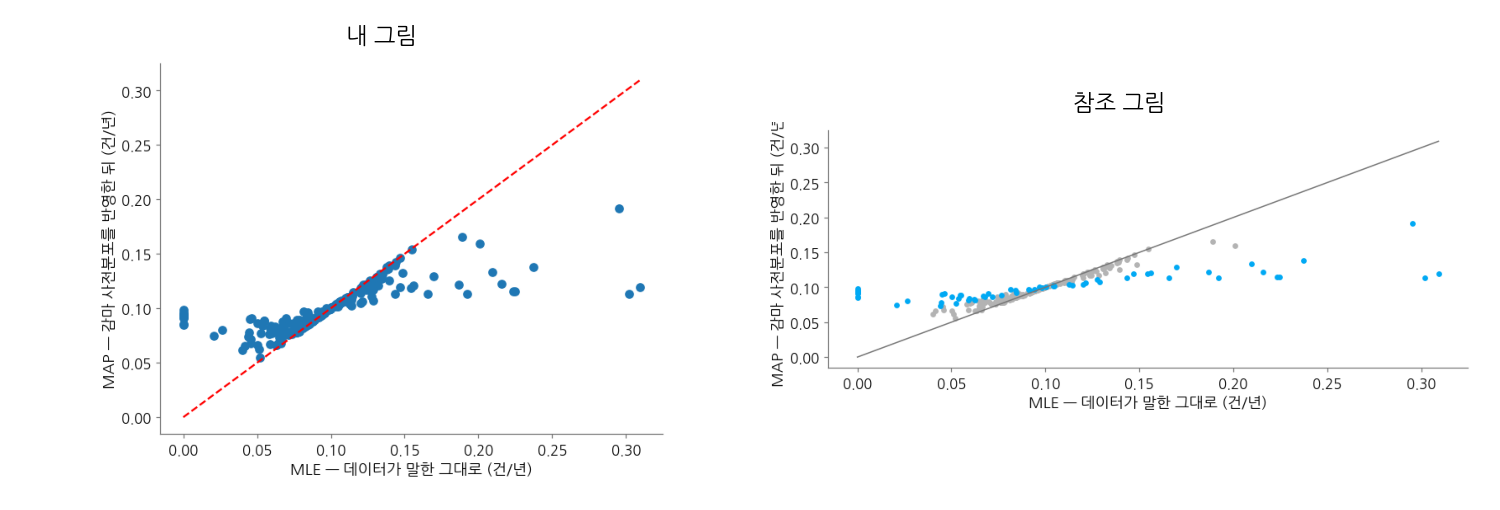

In [7]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
seg_fine, watch, alpha_0, beta_0 는 이미 있으니 다시 만들지 말고 그대로 사용한다.

[MAP 공식]
λ^MAP =(α₀ +∑yi−1) / (β₀ +∑Ei)
분자는 가상 사고 (α₀−1)건과 그 세그먼트의 실제 사고 합을 더한 값, 분모는 가상 노출 β₀년과 그 세그먼트의 실제 노출 합을 더한 값이다.

[할 일]
아래 네 가지를 계산/출력하는 코드를 PROMPT 셀 한 곳에 다 나오게 한다.

1. R21 × B11 세그먼트의 MAP
    - watch 행의 사고건수 합, 노출 합을 위의 MAP 공식에 넣어 계산한다.
   - 단위: 건/년, 소수 여섯 자리로 출력

2. 242개 세그먼트 MAP의 최솟값
   - 242개 세그먼트 전부에 위 MAP 공식을 적용한 뒤, 그중 가장 작은 값을 찾는다.
   - 단위: 건/년, 소수 여섯 자리로 출력

3. 대조용 한 행
    - 같은 세그먼트의 lam_mle 와, lam_mle 가 0 이던 세그먼트 수

4. 그래프 한 장
   - 세그먼트 하나에 점 하나(총242개)인 산점도 그래프를 그린다.
   - 가로축: 세그먼트의 MLE
   - 세로축: 그 세그먼트의 MAP
   - 두 값이 같은 지점을 잇는 y=x 선 하나(0 부터 MLE 최댓값까지)를 긋는다.
   - 가로축 이름: MLE — 데이터가 말한 그대로 (건/년)
   - 세로축 이름: MAP — 감마 사전분포를 반영한 뒤 (건/년)

[출력 형식]
- "이름 = 값 단위" 형태로 한 행씩 print 한다. (표를 통째로 출력하지 않는다)
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
import matplotlib.pyplot as plt

watch_claims = watch["claims"].iloc[0]
watch_exposure = watch["exposure"].iloc[0]
watch_lam_mle = watch["lam_mle"].iloc[0]

watch_map = (alpha_0 + watch_claims - 1) / (beta_0 + watch_exposure)
seg_fine["lam_map"] = (alpha_0 + seg_fine["claims"] - 1) / (beta_0 + seg_fine["exposure"])
min_map = seg_fine["lam_map"].min()

print(f"R21 × B11 MAP = {watch_map:.6f} 건/년")
print(f"242개 세그먼트 MAP 최솟값 = {min_map:.6f} 건/년")
print(f"R21 × B11 lam_mle = {watch_lam_mle:.6f} 건/년"
      f" | lam_mle 0 인 세그먼트 수 = {int((seg_fine['lam_mle'] == 0).sum())} 개")

fig, ax = plt.subplots()
ax.scatter(seg_fine["lam_mle"], seg_fine["lam_map"])
mle_max = seg_fine["lam_mle"].max()
ax.plot([0, mle_max], [0, mle_max], "r--")
ax.set_xlabel("MLE — 데이터가 말한 그대로 (건/년)")
ax.set_ylabel("MAP — 감마 사전분포를 반영한 뒤 (건/년)")
plt.show()

> **[문제] 사고율이 0.00 으로 출력됐던 세그먼트 9개는 내가 그린 산점도에서 세로축이 0 인 위치에 그대로 남아 있다.**
>
> 1. O (맞다)
> 2. X (틀리다)

> **[문제] 사전분포의 강도를 키우면**
>
> 사전분포 Gamma(α₀, β₀)의 강도 β₀ 를 100년에서 10,000년으로 키우되, 사전분포의 최빈값은 전체 계약 사고율에 그대로 맞도록 α₀ = 1 + λ̂·β₀ 로 다시 계산한다고 합시다. 242개 세그먼트 요율표의 MAP는 어떻게 달라질까요? 관측이 적은 세그먼트와 노출이 큰 세그먼트를 나눠서 예측해 보세요.

## 측정 지표를 사고 건수에서 사고 유무로 바꿔도 같은 절차가 적용될까

> **[과제] 과제 제출 — 무사고 환급 이벤트, 대상 규모 추정**
>
> - **무엇을** 무사고 환급 대상 계약 수 한 문장과 두 지역 비교 한 문장, 242개 세그먼트 산점도 한 장을 만듭니다.
> - **무엇으로** 오늘 사용한 데이터 1개로 수행하고, 준비 셀이 242개 세그먼트 집계와 지역 22개 표까지 만들어 둡니다.
> - **인정** 값 4개와 그림이 모두 채점을 통과한 노트북에 브리핑 3문장과 마케팅팀 답신을 추가한 것입니다.
> - **예** 값 행은 「대상 계약 수 = ○○○,○○○ 건」·「R42 가 R43 보다 높을 확률 = 0.○○○○ 확률」 형태입니다.
> - **지표** 오늘 미션과 달리 사고 유무로 측정하므로 R21 x B11 의 값은 계약 12건 중 사고 계약 2건인 비율이고, 그 비율이 MAP 로 수축됩니다.
> 
> - 「PROMPT 셀」을 실행해 값 4개와 그림 1장이 모두 채점을 통과한 상태로 남깁니다.
> - 그 셀의 PROMPT 는 지우지 말고 내가 쓴 그대로 둡니다.
> - 지역 R43 과 R42 의 사후분포를 비교해 어느 쪽이 더 나쁠 확률을 1행으로 출력합니다.
> - 이 절 끝 양식에 브리핑 3문장과 마케팅팀 답신 3문장을 채웁니다.
>
> 마감: 2026-09-30T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 문제 정의 | 「PROMPT 셀」의 PROMPT 에 목표 · 쓸 변수 · 출력 형식이 내 말로 적혀 있다. | 25 |
> | 검증 설계 | 값 4개와 그림이 모두 채점을 통과했고 브리핑 3문장이 채워져 있다. | 25 |
> | 오류 탐지 | 계약이 적은 세그먼트에서 MLE 와 MAP 가 달라지는 이유를 사전분포의 비중 ν/(ν+n) 으로 설명했다. | 25 |
> | 해석·보고 | 마케팅팀 답신이 대상 계약 수를 단위와 함께 제시하고 3문장으로 끝나며, 지역 비교 결과를 확률과 함께 한 문장으로 적었다. | 25 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 또는 Google Drive 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

### 과제 — 무사고 환급 이벤트, 대상 규모 추정

#### 할 일 — 과제 (25분)

1. 아래 「쓸 공식 — 베타분포와 MAP」을 먼저 읽은 뒤, 그 아래 「준비 셀」을 실행합니다. 준비 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 나오는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.
5. 이 절 끝 양식에 브리핑 3문장과 마케팅팀 답신을 채워 제출합니다.

**이 과제의 질문** — 무사고 환급 이벤트의 대상 계약은 몇 건이고, R42 는 R43 보다 정말 더 나쁩니까?

여기서 측정하는 값인 **사고 경험률**은 계약 하나가 기간 중 사고를 한 번이라도 겪는 비율입니다. 건수가 아니라 사고 발생 여부입니다.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg_bin` | 세그먼트 242행 표, 열은 `n` · `s` · `p_mle` | 고정 |
| `p_global` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 | 고정 |
| `nu` | 베타 사전분포의 가상 계약 수 ν = 100건 — 강도 α_b + β_b 는 102 로 2 만큼 큽니다 | 고정 |
| `reg_bin` | 지역 22행 표, 열은 `n` · `s` · `p_mle` | 고정 |
| `rng` | 표본추출의 난수 시드를 고정해 둔 난수 생성기 | 그대로 부른다 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **MLE 로 고른 상위 열 세그먼트의 계약 수** — 단위 건 · 정수
   - 무사고율(= 1 − 사고 경험률)이 높은 순으로 `p_mle` 로 세그먼트 10개를 골라 그 `n` 을 더한 값입니다
2. **MAP 로 고른 상위 열 세그먼트의 계약 수** — 단위 건 · 정수
   - 같은 일을 MAP 열로 한 번 더 합니다. 2개 값이 크게 다르면 명단을 정하는 것이 데이터가 아니라 추정 방법이라는 뜻입니다
   - MAP 열은 아래 「쓸 공식 — 베타분포와 MAP」의 MAP 공식으로 만듭니다
3. **무사고 환급 대상 계약 수** — 단위 건 · 정수
   - `p_global` 을 1 에서 뺀 무사고 비율에 전체 계약 수를 곱합니다. 마케팅팀이 실제로 물어본 숫자가 이 값 1개입니다
4. **R42 가 R43 보다 높을 확률** — 단위 확률 · 소수점 아래 4자리
   - 높다는 것은 사고 경험률 $p$ 가 크다는 뜻이고, 이 확률은 데이터를 고정하고 모수 $p$ 를 무작위로 두는 **사후확률**입니다
   - 두 지역의 사후분포에서 표본 10만 쌍을 추출해 R42 쪽이 더 큰 표본의 비율을 계산합니다
5. **추가할 3개 행** — 채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다
   - R21 × B11 세그먼트의 MAP, 단위 비율 · 소수점 아래 6자리 — 242개 표에서 지역 R21 · 브랜드 B11 행을 골라냅니다
   - 242개 세그먼트 MAP 의 최솟값, 단위 비율 — 브리핑의 위험 항목 근거입니다
   - 두 지역의 사고 경험률 차이 $p_{R42} - p_{R43}$ 의 95% 신용구간, 단위 비율 — 확률은 차이의 방향을, 신용구간은 차이의 크기까지 나타냅니다
6. **그래프 한 장** — 가로축은 세그먼트의 MLE, 세로축은 그 세그먼트의 MAP 인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 242개
   - 대각선 : 가로축 값과 세로축 값이 같은 지점을 잇는 $y = x$ 선 하나, 0 부터 MLE 최댓값까지 곧게 긋습니다
   - 가로축 이름 : 「MLE — 데이터가 말한 그대로 (비율)」
   - 세로축 이름 : 「MAP — 베타 사전분포를 반영한 뒤 (비율)」

**출력 형식** — 값 4개를 「이름 = 값 단위」 형식으로 1행씩 `print` 합니다. 그래프는 한 장입니다.

#### 두 지역 비교 — 고정 규칙 4개

1. 두 지역의 사후분포는 이 과제가 정한 그 베타 사전분포를 지역 표 `reg_bin` 에 그대로 적용해 만듭니다.
2. 확률은 두 사후분포에서 표본 10만 쌍을 추출해 R42 쪽이 더 큰 표본의 비율을 계산합니다(이론 5절 방법 2). 격자 적분(구간을 촘촘한 간격으로 나눠 합을 내는 수치적분)으로 계산해도 같은 값이 나옵니다.
3. 표본추출의 **난수 시드(seed)** 는 「준비 셀」이 `rng` 로 고정해 둡니다. 난수 시드는 난수 생성이 매번 같은 값을 생성하도록 고정해 두는 시작값이라 여러분이 따로 정하지 않습니다.
4. 구간은 같은 표본 10만 쌍에서 두 지역 값의 차이를 계산한 뒤 2.5%·97.5% 백분위수로 냅니다. **신용구간**은 사후분포에서 모수의 값이 95% 확률로 포함되는 구간입니다. 1편의 신뢰구간 95% 는 표집을 반복할 때 구간이 참값을 포함하는 비율이라, 무작위로 두는 대상이 다릅니다.

베타 사전분포를 정하는 공식은 아래 「쓸 공식 — 베타분포와 MAP」에 있습니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `seg_bin` · `p_global` · `nu` · `reg_bin` · `rng` 는 이미 있으니 다시 만들지 말라고 적습니다.
- **사전 설계** — 최빈값을 어디에 맞추고 가상 계약 수를 몇 건으로 설정할지 한 문장으로 명시합니다. 그 문장이 없으면 AI 가 사전분포를 임의로 정합니다.
- **출력** — 값 4개의 이름과 단위, 소수점 아래 몇 자리까지 출력할지.
- **그래프** — 가로축·세로축에 무엇을 배치할지 · 대각선의 양 끝 · 가로축·세로축 이름.

**막히면** — AI 튜터에게 「두 지역의 사후 베타분포에서 추출한 값으로 어느 쪽이 큰지를 어떻게 계산하나요」 처럼 물어보세요.

<details class="lms-extra"><summary>배경 — 마케팅팀의 메일, 그리고 측정 지표가 사고 유무로 바뀌는 지점</summary>

미션 3 에서 242개 세그먼트에 감마 사전분포를 적용해 요율표를 안정시켰죠. 그 표를 보고하려는데 마케팅팀이 메일을 보냅니다 — **"사고를 한 번이라도 내는 계약의 비율이 궁금해요. 무사고 환급 이벤트 대상자 규모를 추정해야 해서요."** 건수가 아니라 유무의 문제라, 측정 지표가 이론 4절에서 구분해 둔 다른 쪽인 **사고 경험률**로 옮겨 갑니다.

사고 경험률은 계약 하나가 기간 중 사고를 한 번이라도 겪을 확률이고, 이론에서 $\hat p = 0.0502$ 로 다룬 그 값입니다. 쓰는 도구는 미션 3 과 같고 분포 가족만 감마에서 **베타**로 바꿉니다.

같은 메일 끝에 한 문장이 더 적혀 있습니다 — **"환급 예산을 지역별로 나눠 배정하려는데, R42 가 R43 보다 정말 더 나쁜가요?"** 값 2개 0.0564 와 0.0407 을 나열하는 것만으로는 어느 쪽이 더 나쁜지에 대한 답이 되지 않습니다. 이론 5절은 균등 사전분포로 두 지역의 사후분포를 비교해 0.980 이라는 확률을 산출했습니다. 과제에서는 같은 비교를 회사의 경험을 반영한 사전분포로 다시 계산합니다.

계약 6건인 세그먼트에서 "이 세그먼트는 사고를 안 낸다"는 값이 나와 버리는 큰 변동은 유무로 바꿔도 그대로입니다. 그래서 사전분포도 미션 3 과 같은 원칙으로 정합니다 — 최빈값은 전체 계약의 사고 경험률에 맞추고, 가상 계약 수는 100건으로 둡니다.

</details>

#### 쓸 공식 — 베타분포와 MAP

포아송분포의 켤레 사전분포가 감마분포였듯, 사고 유무의 켤레 사전분포는 **베타분포**입니다. 베타분포는 0 과 1 사이에서만 확률밀도가 정의되는 분포족이고, 모수 2개 $\alpha_b$·$\beta_b$ 로 모양이 정해집니다. 아래 첨자 $b$ 는 「베타 사전분포의 모수」라는 표시로, 미션 3 의 감마 사전분포 모수 $\alpha_0$·$\beta_0$ 와 뜻이 다른 모수이므로 기호를 구분해 씁니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Beta_distribution_pdf.svg" width="480" height="384"/>
<p align="center"><em>▲ 모수 조합이 다른 베타분포 5개 — α 와 β 의 비가 평균 α/(α+β) 를, 둘의 합 α+β 가 강도를 정한다. 최빈값 (α−1)/(α+β−2) 는 따로 읽는다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikimedia Commons, Beta distribution pdf.svg</span></p>

우리가 정할 사전분포 Beta(6.0, 96.0) 은 최빈값이 주황 곡선 α=2·β=5 의 0.2 보다 더 왼쪽인 0.05 에 위치하고 곡선도 더 좁습니다. 범례는 위에서부터 빨강 α=β=0.5, 파랑 α=5·β=1, 초록 α=1·β=3, 보라 α=β=2, 주황 α=2·β=5 순서입니다. 빨강은 양 끝이 높은 U 자, 파랑은 오른쪽 끝으로 갈수록 높아지는 곡선, 초록은 가장 왼쪽이 제일 높고 오른쪽으로 내려가는 곡선, 보라는 최빈값이 0.5 인 좌우대칭 곡선, 주황은 최빈값이 0.2 인 곡선입니다. 가상 관측은 $\alpha_b - 1$ 회 성공·$\beta_b - 1$ 회 실패로 읽습니다 — Beta(6, 96) 은 가상 계약 100건 중 사고 계약 5건을 미리 관측한 것과 같습니다.

**갱신 규칙**도 감마 때와 같은 덧셈입니다. 그 세그먼트의 계약 $n$ 건 중 사고 계약이 $s$ 건이면, **사고 계약 $s$ 는 $\alpha_b$ 에, 무사고 계약 $n - s$ 는 $\beta_b$ 에 그냥 더합니다**. 사후분포는 $\text{Beta}(\alpha_b + s,\ \beta_b + n - s)$ 이고, 그 최빈값을 요율로 쓰는 것이 MAP 입니다.

$$
\hat p_{\text{MAP}} = \frac{\alpha_b + s - 1}{\alpha_b + \beta_b + n - 2}
$$

이론 3절의 베타-베르누이 MAP $\frac{\alpha_0 + k - 1}{\alpha_0 + \beta_0 + n - 2}$ 와 같은 식이고, 성공 횟수 $k$ 항에 그 세그먼트의 사고 계약 수 $s$ 를 대입한 것뿐입니다.

$\alpha_b$·$\beta_b$ 는 사전분포의 모수 2개이고, $s$ 는 그 세그먼트의 사고 계약 수, $n$ 은 그 세그먼트의 계약 수로 단위는 둘 다 건입니다. 분자에서 1 을, 분모에서 2 를 각각 한 번씩 빼는 단계가 최빈값을 구하는 계산입니다. 사후분포의 평균을 읽으면 이 뺄셈 2회가 없습니다.

사전 설계도 미션 3 과 같은 원칙 2개입니다 — **최빈값은 전체 계약의 사고 경험률 $\hat p$ 에 맞추고, 가상 계약 수는 $\nu$ 건으로 지정합니다.** $\nu$ 는 그리스 문자 뉴입니다. 「준비 셀」이 $\nu = 100$ 건으로 지정하고 그 값을 `유효 표본 수 nu` 로 출력하는데, 사전분포의 **강도** $\alpha_b + \beta_b$ 는 그보다 2 큰 102 입니다. 가상 관측 수와 강도가 2 만큼 다른 것은 최빈값 기준으로 모수를 정했기 때문입니다.

<details class="lms-hint"><summary>사전분포 Beta(6.02, 95.98) 이 나오는 유도</summary>

<img src="https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-01-09-Bayes_rule/pic1.png" width="640" height="305"/>
<p align="center"><em>▲ 베이즈 정리 한 식 — 빨간 상자가 사후 P(H|E), 파란 상자가 사전 P(H) 이고, 과제에서 H 는 그 세그먼트의 사고 경험률 p 다. 분모 P(E) 는 상수라 비례식에서 빠지므로, 과제에서 바꾸는 것은 구조가 아니라 사전분포의 분포족뿐이다</em><br><span style="font-size:0.9em;color:#656565">출처: 공돌이의 수학정리노트, angeloyeo.github.io</span></p>

**가상 계약 수**란 데이터를 보기 전에 계약 $\nu$ 건을 이미 관측했다고 가정한다는 뜻입니다. 위 원칙 2개를 MAP 공식에 대입해 풀면 $\alpha_b - 1 = \hat p\,\nu$, $\beta_b - 1 = (1 - \hat p)\,\nu$ 라는 식 2개가 나옵니다. 전체 계약의 사고 경험률 $\hat p = 0.0502$ 와 $\nu = 100$ 을 대입하면 $\alpha_b = 6.02$·$\beta_b = 95.98$ 입니다. 그러면 $\alpha_b + \beta_b - 2 = \nu$ 가 되어 MAP 는 다음과 같이 정리됩니다.

$$
\hat p_{\text{MAP}} = \frac{\hat p\,\nu + s}{\nu + n}
$$

**가상 계약 $\nu$ 건과 실계약 $n$ 건을 합쳐 사고 경험률을 계산한 값**이라는 뜻입니다. 최빈값 기준으로 읽으면 사전분포의 비중은 정확히 $\nu / (\nu + n)$ 입니다. 사후분포의 평균으로 읽으면 강도를 그대로 쓴 $(\alpha_b + \beta_b)/(\alpha_b + \beta_b + n)$ 이라 값이 조금 다릅니다. 계약 12건인 세그먼트에서는 $100/112$ 로 분모의 약 89%를 사전분포가 차지하고, 계약이 수만 건인 세그먼트에서는 0.2% 미만으로 감소합니다. 미션 3 에서 노출로 계산하던 비중을 계약 수로 바꾼 것뿐입니다.

</details>

In [8]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 앞 미션을 안 돌렸으면 맨 위 설치 셀과 이 셀을 실행합니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)          # 사고를 한 건이라도 냈으면 1, 아니면 0
p_global = float(df["HasClaim"].mean())                   # 쓸 변수 1 — 전체 계약의 사고 경험률 (비율)
nu = 100.0                                                # 쓸 변수 2 — 사전분포의 유효 표본 수 = 가상 계약 수 (건)

# 세그먼트 집계와 MLE 까지는 완성해 두었습니다 (미션 2·3 과 같은 Region x VehBrand 242개)
seg_bin = (df.groupby(["Region", "VehBrand"], observed=True)
             .agg(n=("HasClaim", "size"), s=("HasClaim", "sum"))
             .reset_index())
seg_bin["p_mle"] = seg_bin["s"] / seg_bin["n"]

reg_bin = (df.groupby("Region", observed=True)            # 쓸 변수 3 — 지역 22개 표 (세그먼트 대신 지역)
             .agg(n=("HasClaim", "size"), s=("HasClaim", "sum"))
             .reset_index())
reg_bin["p_mle"] = reg_bin["s"] / reg_bin["n"]
rng = np.random.default_rng(0)                            # 쓸 변수 4 — 표본추출의 난수 시드를 고정합니다

print(f"세그먼트 {len(seg_bin)}개 | 컬럼 {list(seg_bin.columns)}")
print(f"전체 계약의 사고 경험률 p_global : {p_global:.6f} (비율)"
      f" | 사전분포의 유효 표본 수 nu = {nu:.0f} 건")
print(f"사고 경험률이 0 으로 계산된 세그먼트 : {int((seg_bin['p_mle'] == 0).sum())} 개")
print(f"전체 계약 {int(seg_bin['n'].sum()):,}건 — 242개 세그먼트의 계약 수를 모두 더한 값입니다")
print("\n[계약 수가 가장 적은 세그먼트 8개 — 지금은 MLE 만]")
print(seg_bin.nsmallest(8, "n").round(4).to_string(index=False))
_two_regions = reg_bin.set_index("Region")
print(f"\n지역 {len(reg_bin)}개"
      f" | R43 계약 {int(_two_regions.loc['R43', 'n']):,}건 중 사고 계약 {int(_two_regions.loc['R43', 's'])}건"
      f" · R42 계약 {int(_two_regions.loc['R42', 'n']):,}건 중 {int(_two_regions.loc['R42', 's'])}건")
print("\n쓸 수 있는 이름 :  seg_bin (n · s · p_mle 열) · p_global · nu"
      " · reg_bin (n · s · p_mle 열) · rng")

세그먼트 242개 | 컬럼 ['Region', 'VehBrand', 'n', 's', 'p_mle']
전체 계약의 사고 경험률 p_global : 0.050235 (비율) | 사전분포의 유효 표본 수 nu = 100 건
사고 경험률이 0 으로 계산된 세그먼트 : 9 개
전체 계약 678,013건 — 242개 세그먼트의 계약 수를 모두 더한 값입니다

[계약 수가 가장 적은 세그먼트 8개 — 지금은 MLE 만]
Region VehBrand  n  s  p_mle
   R42      B14  6  0 0.0000
   R21      B14  8  0 0.0000
   R43      B11  8  0 0.0000
   R21      B11 12  2 0.1667
   R43      B10 15  0 0.0000
   R94      B14 18  0 0.0000
   R94      B10 19  0 0.0000
   R43      B14 20  0 0.0000

지역 22개 | R43 계약 1,326건 중 사고 계약 54건 · R42 계약 2,200건 중 124건

쓸 수 있는 이름 :  seg_bin (n · s · p_mle 열) · p_global · nu · reg_bin (n · s · p_mle 열) · rng


MLE_top10_n = 239 건
MAP_top10_n = 8879 건
환급_대상_계약수 = 643953 건
P(R42>R43) = 0.9767 확률
R42-R43_95%CI = [0.000196, 0.028332] 비율
R21xB11_MAP = 0.062710 비율

──────────────────────────────────────────────────────
◼ 과제 채점 결과
✅ MLE 로 고른 상위 열 세그먼트의 계약 수 (건) — 출력에서 239 를 찾았습니다
✅ MAP 로 고른 상위 열 세그먼트의 계약 수 (건) — 출력에서 8,879 를 찾았습니다
✅ 무사고 환급 대상 계약 수 (건) — 출력에서 643,953 를 찾았습니다
✅ R42 가 R43 보다 높을 확률 (확률) — 출력에서 0.9767 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


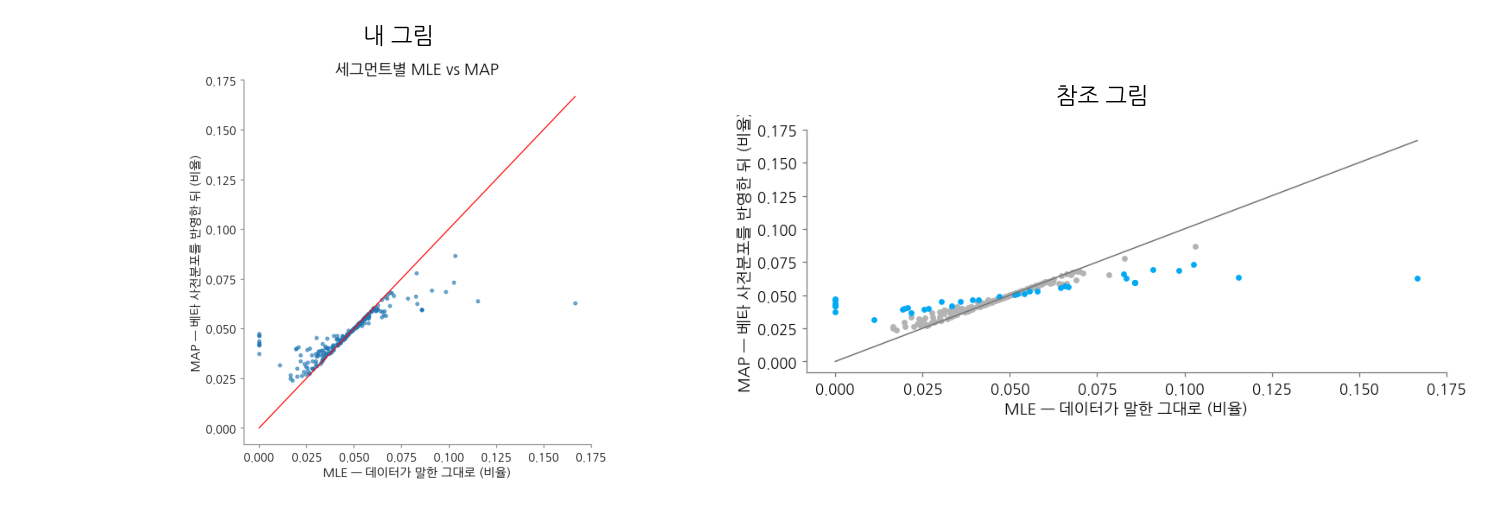

In [9]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
seg_bin, p_global, nu, reg_bin, rng는 이미 있으니 다시 만들지 말고 그대로 사용한다.

[사전 설계]
베타 사전분포의 최빈값은 전체 계약의 사고 경험률 p_global에 맞추고, 가상 계약 수는 nu(=100건)로 지정한다. 

[두 지역 비교 고정 규칙 4개]
- 두 지역의 사후분포는 이 사전분포를 reg_bin에 그대로 적용해 만든다.
- R42가 R43보다 높을 확률은 두 사후분포에서 표본 10만 쌍을 추출해 R42 쪽이 더 큰 표본의 비율로 계산한다.
- 표본추출의 난수 시드는 rng로 고정한다.
- 신용구간은 같은 표본 10만 쌍에서 두 지역 값의 차이를 계산한 뒤, 2.5%·97.5% 백분위수로 낸다.

[할 일]
아래 여섯가지를 계산/출력하는 코드를 PROMPT 셀 한 곳에 다 나오게 한다.

1. MLE 로 고른 상위 열 세그먼트의 계약 수
    - 무사고율(= 1 − 사고 경험률)이 높은 순으로 p_mle 로 세그먼트 10개를 골라 그 n 을 더한 값이다.
   - 단위: 건, 정수로 출력

2. MAP 로 고른 상위 열 세그먼트의 계약 수
   - 같은 일을 MAP 열로 한 번 더 한다.
   - MAP 열은 아래 MAP 공식으로 만든다.
    - p̂_MAP = (α_b + s − 1) / (α_b + β_b + n − 2)
    - s는 그 세그먼트의 사고 계약 수, n은 그 세그먼트의 계약 수다.
    - 무사고율(1−MAP)이 높은 순으로 10개를 고르고, 그 n을 더한 값이다.
   - 단위: 건, 정수로 출력

3. 무사고 환급 대상 계약 수
   -  p_global을 1에서 뺀 무사고 비율에 전체 계약 수를 곱한다.
   - 단위: 건, 정수로 출력

4. R42 가 R43 보다 높을 확률
   - "높다"는 것은 사고 경험률 p가 더 크다는 뜻이다.
   - 위 [두 지역 비교 고정 규칙 4개]를 그대로 따른다.
   - 단위: 확률, 소수점 아래 4자리로 출력

5. 대조용 한 행
    - R21 × B11 세그먼트의 MAP: 242개 표에서 지역 R21·브랜드 B11 행을 골라낸다 (단위: 비율, 소수 여섯째 자리) 
    - 242개 세그먼트 MAP의 최솟값 (단위: 비율)
    - 두 지역의 사고 경험률 차이(p_R42 − p_R43)의 95% 신용구간 (단위: 비율)

6. 그래프 한 장
   - 세그먼트 하나에 점 하나(총242개)인 산점도 그래프를 그린다.
   - 가로축: 세그먼트의 MLE
   - 세로축: 그 세그먼트의 MAP
   - 두 값이 같은 지점을 잇는 y=x 선 하나(0 부터 MLE 최댓값까지)를 긋는다.
   - 가로축 이름: MLE — 데이터가 말한 그대로 (비율)
   - 세로축 이름: MAP — 베타 사전분포를 반영한 뒤 (비율)

[출력 형식]
- "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

# 1) 베타 사전분포 파라미터: 최빈값 = p_global, 강도(alpha_b+beta_b-2) = nu
alpha_b = nu * p_global + 1
beta_b = nu * (1 - p_global) + 1

# seg_bin에 MAP 열 추가
seg_bin = seg_bin.copy()
seg_bin["pmap"] = (alpha_b + seg_bin["s"] - 1) / (alpha_b + beta_b + seg_bin["n"] - 2)

# 1. MLE 상위 10 무사고율 세그먼트 계약 수
top10_mle_n = seg_bin.sort_values("p_mle", ascending=True).head(10)["n"].sum()
print(f"MLE_top10_n = {int(top10_mle_n)} 건")

# 2. MAP 상위 10 무사고율 세그먼트 계약 수
top10_map_n = seg_bin.sort_values("pmap", ascending=True).head(10)["n"].sum()
print(f"MAP_top10_n = {int(top10_map_n)} 건")

# 3. 무사고 환급 대상 계약 수
total_n = seg_bin["n"].sum()
target_n = (1 - p_global) * total_n
print(f"환급_대상_계약수 = {int(round(target_n))} 건")

# 4. R42 vs R43 사후 비교 (Region 열로 필터링)
r42 = reg_bin[reg_bin["Region"] == "R42"].iloc[0]
r43 = reg_bin[reg_bin["Region"] == "R43"].iloc[0]

a42 = alpha_b + r42["s"]
b42 = beta_b + (r42["n"] - r42["s"])
a43 = alpha_b + r43["s"]
b43 = beta_b + (r43["n"] - r43["s"])

samp42 = rng.beta(a42, b42, size=100_000)
samp43 = rng.beta(a43, b43, size=100_000)

prob_r42_higher = (samp42 > samp43).mean()
print(f"P(R42>R43) = {prob_r42_higher:.4f} 확률")

diff = samp42 - samp43
ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
print(f"R42-R43_95%CI = [{ci_low:.6f}, {ci_high:.6f}] 비율")

# 5. 대조용 값
# 주의: seg_bin도 reg_bin처럼 "Region" 열이 있을 것으로 보고, 브랜드 열 이름을 "Brand"로 가정함
r21b11_map = seg_bin[
    (seg_bin["Region"] == "R21") & (seg_bin["VehBrand"] == "B11")
]["pmap"].iloc[0]
print(f"R21xB11_MAP = {r21b11_map:.6f} 비율")

# 6. 산점도
plt.figure(figsize=(6, 6))
plt.scatter(seg_bin["p_mle"], seg_bin["pmap"], s=10, alpha=0.6)
max_val = seg_bin["p_mle"].max()
plt.plot([0, max_val], [0, max_val], color="red", linewidth=1)
plt.xlabel("MLE — 데이터가 말한 그대로 (비율)")
plt.ylabel("MAP — 베타 사전분포를 반영한 뒤 (비율)")
plt.title("세그먼트별 MLE vs MAP")
plt.show()

# [브리핑]
결론: 무사고 환급 대상은 계약 643,953 건(전체 678,013건의 약 94.98%)으로 추정합니다.

위험: 관측이 적은 세그먼트의 MLE는 우연에 의해 극단적으로 튈 수 있어 MAP로 보정한 값을 써야 합니다.

코드가 답을 만드는 방식: 사전분포의 가상 사고 5건과 실제 사고 건수를 더 한 것을 가상 계약 ν(=100건)과 세그먼트의 실계약 n건을 더한 것으로 나눠 MAP를 계산했습니다. 실제 계약(n)이 적을수록 가상 계약(ν=100건)의 비중이 커져 결과가 전사 평균 쪽으로 더 크게 끌려갑니다.

# [마케팅팀 답신]
결론: 무사고 환급 대상은 계약  643,953 건으로 추정됩니다.

근거: 무사고율(= 1 − 사고 경험률)에 전체 계약 수를 곱해서 산출했습니다.

한계: 계약 수가 적은 세그먼트의 원본 비율(MLE)을 그대로 쓰면 안 되며 사전분포로 보정한 값(MAP)을 사용해야 합니다. 또한, R42 가 R43 보다 높을 확률은 어느 지역이 더 위험한지 방향만 말해줄 뿐 그 차이가 실제로 큰지는 95% 신용구간을 함께 봐야 판단할 수 있습니다.

**브리핑 3문장** — 아래 3문장을 이 셀에 그대로 채워 제출합니다. 값과 그림이 모두 채점을 통과한 뒤에 씁니다. 만들 것 5번에서 이미 출력한 「242개 세그먼트 MAP 의 최솟값」을 위험 항목의 근거로 씁니다. 그 값이 0 보다 크면 사고 경험률이 0 으로 계산되던 세그먼트가 하나도 남지 않았다는 뜻입니다.

> **결론**: 무사고 환급 대상은 계약 ____ 건(전체 ____ 건의 ____%)으로 추정합니다.
>
> **위험**: ____ (관측이 적은 세그먼트에서 어떤 값을 그대로 쓰면 안 되는지 한 문장)
>
> **코드가 답을 만드는 방식**: ____ (사전분포의 가상 계약 $\nu$ 건과 이 세그먼트의 실계약 $n$ 건을 어떻게 합쳐 비율을 냈는지 한 문장)

**마케팅팀 답신** — 브리핑 바로 아래에 다음 3문장을 채웁니다. 브리핑이 우리 팀에 쓰는 글이라면, 답신은 마케팅팀에 보내는 글입니다.

> **결론**: 무사고 환급 대상은 계약 ____ 건으로 추정됩니다.
>
> **근거**: ____ (이 숫자를 어떤 데이터로 어떻게 냈는지 한 문장)
>
> **한계**: ____ (세그먼트별로 명단을 나눌 때 어떤 값을 그대로 쓰면 안 되는지, 그리고 내가 출력한 「R42 가 R43 보다 높을 확률」이 방향만 말하고 크기는 95% 신용구간이 말한다는 점을 한 문장)

## 오늘의 정리 — 내일은 계약별 요율로

프라이싱 분석가로서 2일차 보고를 정리합니다. 오늘의 목표는 4개였습니다 — 한 숫자 · 242개 세그먼트 요율표 · 수축 · 사고 유무로의 전환입니다. 아래 표는 그 순서대로 정리한 것입니다. 앞 절반의 답은 **노출 1년당 0.1006건**입니다. 다만 그 값을 세그먼트 요율로 적용하면 세그먼트마다 추정값의 표본 변동이 크다는 것까지가 오늘 함께 얻은 답입니다. 그래서 보고서에 포함되는 것은 숫자 하나가 아니라 세그먼트별 MLE 와 MAP, 242개 세그먼트의 추정값 2종입니다.

| 오늘의 질문 | 우리가 얻은 답 |
|---|---|
| 포트폴리오의 연간 사고율은? | 포아송 MLE $\hat{\lambda}$ — 사고 건수의 합을 **노출의 합**으로 나눈 한 숫자 (건/년) |
| 계약당 평균 사고 건수를 쓰면 안 되나? | 노출(평균 0.53년)을 무시한 왜곡 — 연간 기준의 절반쯤으로 과소평가됩니다 |
| 242개 세그먼트 요율표의 문제는? | 관측이 적은 세그먼트에서 MLE 가 0.00 부터 전체 계약 사고율의 3배까지 크게 변동합니다 |
| 어떻게 안정화했나? | 감마 사전분포(가상 노출 100년) × 우도 → 사후분포의 최빈값(MAP)으로 수축 |
| 사고 '유무'로 바꾸면? | 켤레 사전분포를 감마에서 베타로 바꿔도 같은 절차가 성립하는지 — 과제에서 직접 확인합니다. 감마의 강도는 가상 노출 β₀ 이고 베타의 강도는 α+β 입니다 |
| 지역 2개 중 어느 쪽이 더 나쁜가? | 사후분포를 비교해 **확률 하나**로 답합니다 — 과제에서 직접 확인합니다 |

MLE 와 MAP 의 관계는 다음 표와 같습니다.

| | MLE | MAP |
|---|---|---|
| 최대화 대상 | 로그우도 $\ell(\lambda)$ | 로그 사후(정규화 상수 제외) $\ell(\lambda) + \log P(\lambda)$ — 최댓값의 위치만 사후분포와 같습니다 |
| 쓰는 정보 | 데이터만 | 데이터 + 사전지식 |
| 관측이 적은 세그먼트에서 | 표본 변동에 따라 크게 달라짐 | 사전분포 쪽으로 수축해 안정 |
| 관측이 많은 세그먼트에서 | 좋은 추정 | MLE 로 수렴 (사전분포의 영향이 사라짐) |
| 사전분포가 균등분포면(α₀ = 1) | — | 최빈값(MAP)이 MLE 와 동일 — 사후분포의 평균은 다릅니다. 가상 관측 0회지만 강도가 0 인 것은 아닙니다 |

오늘 확정한 것은 2개입니다. 하나는 **전처리 규칙**으로 `ClaimNb` 4건 절사와 `Exposure` 1년 상한이고, 다른 하나는 **242개 세그먼트 요율표의 추정값 2종**인 세그먼트별 MLE 와 MAP 입니다. 이 2개가 내일의 출발점입니다.

## 내일 예고 — 세그먼트 평균으로는 부족하다

오늘 만든 요율표에는 구조적 한계가 있습니다. **같은 세그먼트 안의 계약은 전부 같은 요율을 받는다**는 것. 같은 지역에 살아도 20세 신규 운전자의 스포츠카와 50세 무사고 베테랑의 경차가 같은 보험료를 부과하는 것이 타당할까요? 세그먼트를 더 나누자니 오늘 본 변동이 더 심해질 뿐입니다.

내일은 접근 방법을 바꿉니다. 세그먼트를 나누는 대신 **계약 한 건 한 건의 특성을 입력으로 받아 그 계약만의 사고율 $\lambda_i$ 를 계산하는 회귀 모형**을 만듭니다. 특성은 나이·차량·지역·할증점수입니다. 사용하는 데이터는 오늘과 동일합니다.

내일도 포아송 우도·로그우도 최대화·노출 보정을 그대로 사용합니다. 회귀 모형의 학습이 오늘 배운 MLE 를 계수 여러 개로 확장한 것임을 확인합니다. 내일 만들 첫 모형은 설명변수가 없는 절편만의 모형(intercept-only)인데, 그 예측값이 오늘의 $\hat{\lambda}$ 와 정확히 일치하는지 확인하는 것으로 하루를 시작하겠습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Regression_de_Poisson.svg" width="480" height="360"/>
<p align="center"><em>▲ 포아송 회귀의 산점도와 적합 곡선 <code>ln(λ) = 2x + 0.5</code> — 계약 특성 <code>x</code> 가 0 에서 1 로 가는 동안 곡선이 나타내는 기대 사고 건수가 1.6건에서 12건으로 증가하니, 오늘 구한 상수 λ̂ 가 내일은 계약마다 값이 달라지는 이 곡선으로 확장된다</em><br><span style="font-size:0.9em;color:#656565">출처: Wikimedia Commons, Regression de Poisson.svg, CC0</span></p>

가로축 <code>Variable explicative x</code> 는 계약이 가진 특성 하나이고, 세로축 <code>Résultats de décompte</code> 는 그 계약에서 관측된 사고 건수입니다(프랑스어로 만든 그림이라 라벨이 프랑스어입니다). 파란 점 하나가 계약 하나이고, 주황 곡선은 특성 <code>x</code> 로부터 그 계약만의 사고율 λ 를 계산해 주는 모형이라, 왼쪽에서 드물고 오른쪽으로 갈수록 잦아지는 이 모양이 곧 요율 차등의 근거가 됩니다.

오늘의 마무리 절차는 다음과 같습니다. 오늘 열린 완성본 풀이와 내 코드가 달랐던 지점 1곳을 떠올린 뒤, 이 절 마지막 퀴즈의 3문장을 채워 팀 채널에 올리고 다른 사람의 답을 읽는 것이 오늘의 마지막 복습입니다. 함께 볼 팀이 없다면 내일의 나에게 남기는 메모로 적어 두어도 효과는 같습니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 모형추정 Day 2 완료</h2>
<div style="color:#656565">어제 적은 우도에 회사의 사전지식을 더해 관측이 적은 세그먼트의 표본 변동을 줄였습니다.<br/>내일은 이 도구로 계약 한 건 한 건의 요율을 계산합니다.</div>
</div>

> **[문제] 요율표 초안을 그대로 사용해도 될까**
>
> 미션 2 가 만든 242개 세그먼트 요율표에는 연간 사고율이 0.00 으로 출력된 세그먼트가 9개 있고, 가장 높은 세그먼트는 전체 계약 사고율의 3배 수준이었습니다. 팀장이 이렇게 말합니다. "0.00 인 세그먼트는 보험료를 최저로 내리고, 3배인 세그먼트는 그대로 3배를 받읍시다." (가) 이 표를 그대로 요율로 쓰면 안 되는 이유를 '증거의 양'이라는 말로, (나) 오늘 그 두 종류의 세그먼트를 어떤 방법으로 고쳤는지, (다) 그 방법이 계약이 수만 건인 대형 세그먼트는 왜 거의 조정하지 않는지 — 3문장으로 적어 보세요.